# Prosjekt 3

In [18]:
# Biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy

## Test

In [19]:
x = np.linspace(0, 1, 10)
y = [4, 5, 2, 7, 8, 9, 20, 30, 4, 60]

#plt.plot(x, y, color = 'cornflowerblue')
plt.show()


## Oppgave 1

### Oppgave 1a)

$ \frac{d^2 y}{(d x)^2}  = -4 * \sin(2x)$

Flytter dx^2 over på høyre side og integrerer to ganger.

$ \int{dy^2} = \int{-4*\sin(2x) dx^2} $

$dy = (4 * \frac{1}{2} \sin(2x) + C)dx$

$\int{dy} = \int{(4 * \frac{1}{2} \sin(2x) + C)dx}$ 


### Oppgave 1b)

### Oppgave 1c)

497
498


/var/folders/0z/tw9hz21n1_3dwbj7jhj3n27r0000gn/T/ipykernel_8036/3879595488.py:92: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


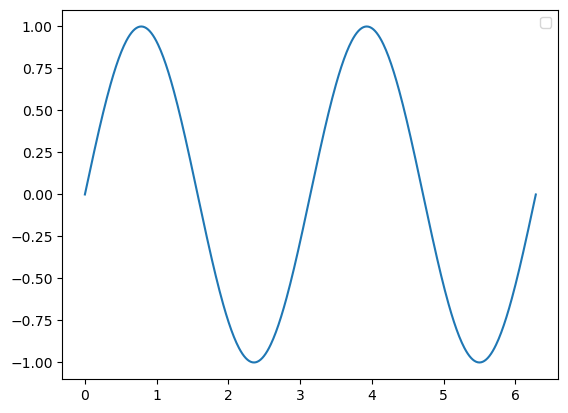

In [20]:
"""def y_array():
    y_arr = np.array()
    
    i = 0
    for x in range(x_start, x_slutt, h): #må finne en måte å oppdatere steglengden h
        y_arr[i] = y(x)
        i += 1
        y_arr[i] = y_derivert(x)
        i += 1
    return y_arr"""

def f(x, y):
    return np.array([y[1], -4 * np.sin(2*x)])


def rk3 (x_start, x_slutt, y_0, h_0, tol, alpha, f):
   
    n, m = 0, 0                       # antall steg
    x_verdier = [x_start]
    y_verdier = [y_0]
    h_verdier = np.array([])    # array til å lagre steglengde

    # Verdier som skal bli oppdatert i while løkken
    x = x_start
    y = np.array(y_0)
    k1 = f(x,y)
    h = h_0
    
    while (x_slutt - x) > 0:

        h = min(h, x_slutt - x)
        # Legger steget til i en liste
        h_verdier = np.append(h_verdier, h)

        k2 = f(x +h/2, y+ h*k1/2)
        k3 = f(x + 3*h/4, y + 3*h*k2/4)

        y_neste = y + h* (2*k1 + 3*k2 + 4*k3)/9

        k4 = f(x + h, y_neste)

        z_neste = y + 1/24*h*(7*k1 + 6*k2 + 8*k3 + 3*k4)

        est = np.linalg.norm(y_neste - z_neste)
        
        if est < tol: #akseptert
            x += h
            y = y_neste
            k1 = k4
            n += 1
            # Oppdater x_verdier og y_verdier
            x_verdier.append(x)
            y_verdier.append(y)

        # Regn ut h_ny og la h = h_ny:
        h_ny = alpha * h *(tol/est)**(1/3)
        h = h_ny

        m += 1
    # Gjør om x_verdier og y_verdier til array
    x_verdier = np.array(x_verdier)
    y_verdier = np.array(y_verdier)
    
    # Funskjonen skal returnere:
    # x et numpy attay 
    # y løsningen på posisjon x_n, 2D array
    # h, steglengde
    # n, antall steg
    return x_verdier, y_verdier, h_verdier, n, m

# Verdier
x_start = 0
x_slutt = 2*np.pi
h_0 = np.pi / 100
y_0 = np.array([0, 2])

alpha = 0.8
tol = 10e-7

x_verdier, y_verdier, h, n, m = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, f)

plt.plot(x_verdier, y_verdier[:,0])
#plt.plot(x_verdier, y_verdier[:,1])
#plt.plot(x_verdier, h)

# Analytisk løsning

#plt.plot(x_verdier, y_anal(x_verdier), color = "cornflowerblue", label = "y(x)")
#plt.plot(x_verdier, y_derivert(x_verdier), color = "plum", label = "y'(x)")
print(n)
print (m)
plt.legend()
plt.show()

### Oppgave 1d

498
498


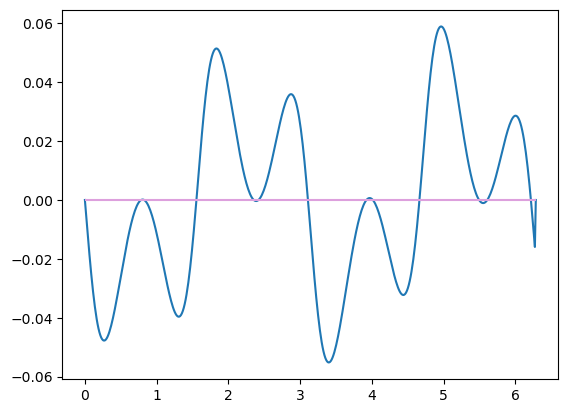

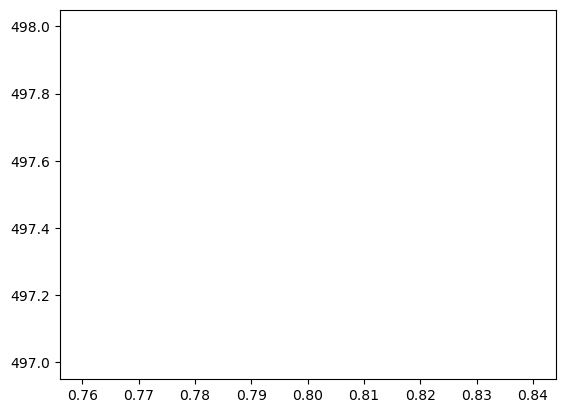

In [21]:
x_verdier1 = np.linspace(0, 2*np.pi, n+1) #n hentes fra oppgave 1c (rk3)
def y_anal (x):
    return np.sin(2*x)

y_anal_verdier = y_anal(x_verdier1)

error = y_anal_verdier - y_verdier[:,0]

print(y_anal_verdier.size)
print(y_verdier[:,0].size)

plt.plot(x_verdier1, error)
plt.hlines(tol, x_start, x_slutt, color = 'plum')
plt.show()

alphas = np.linspace
plt.plot(alpha,n , color = 'r')
plt.plot(alpha, m, color = 'b')
plt.show()

###     Oppgave 1e)

In [22]:
def g(z):
    return z + np.sin(z) + np.cos(z)

def sekant_metoden (g, z0, z1, tol):
    z = [z0, z1]

    # Løser for z[2] utenfor løkken, ellers får man out of range pga. abs(z[n-1] - z[n])       
    n = 2
    z.append((z[n-2]*g(z[n-1]) - z[n-1]*g(z[n-2])) / (g(z[n-1]) - g(z[n-2])))

    while abs(z[n-1] - z[n]) > tol:
        n+=1
        z.append((z[n-2]*g(z[n-1]) - z[n-1]*g(z[n-2])) / (g(z[n-1]) - g(z[n-2])))
        
        #print(f"\nAbsolutt verdi i {n}: {abs(z[n-1] - z[n])}")
        #print(f"z[n] = {z[n]}")
        
    g_rot = z[-1]
    return g_rot

# startverdier
z_0 = 0
z_1 = 4
tol = 10e-10

# Finner roten til g(z) = z + sin(z) + cos(z)
g_rot = sekant_metoden (g, z_0, z_1, tol)
print(f"Roten til g(z) = z + sin(z) + cos(z) er {g_rot:.5f}")


Roten til g(z) = z + sin(z) + cos(z) er -0.45662


### Oppgave 1f)

In [23]:
# løser IVP for en gitt ukjent startverdi b
def løs_med_b (b):
    y_0 = np.array([0, b])
    x_verdier_f, y_verdier_f, h, n = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, f)

    return y_verdier_f[-1, 0] # = y(b)    [siste rad = b, første kolonne = y]

# Residual, F(s) - s
def residual(s):
    # B er ønsket verdi y(b)
    return løs_med_b(s) - B

# Verdier
b0 = 0          # b er verdien som gir yb(2pi) = 0
b1 = np.pi
y_0 = 0
y_2pi = 0
x_start = 0
x_slutt = 2*np.pi
h_0 = np.pi / 100
alpha = 0.8
tol = 10e-7

# finn rett b
riktig_b = sekant_metoden(residual, b0, b1, tol)

# løs med riktig b
y_0_rett = np.array([0, riktig_b])
x_verdier_f, y_verdier_f, h, n = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, f)

plt.plot(x_verdier_f, y_verdier_f)
plt.show()

ValueError: too many values to unpack (expected 4)

### Oppgave 1h)

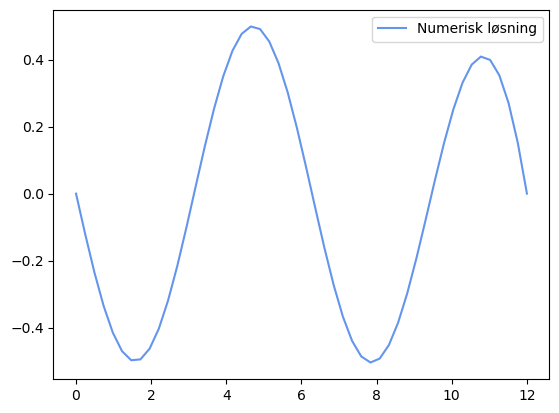

In [ ]:
#Use the scipy function solve_bvp to solve eq. from task 1g)
from scipy.integrate import solve_bvp

def f(x, y):
    return [y[1], y[0]+ np.sin(x)]

#Grensebetingelser: y(0) = y(12) = 0
def bc(ya, yb):
    return [ya[0]-0, yb[0]-0]


x = np.linspace(0, 12)

y_init = np.zeros((2, x.size))
#y_init[0] = np.linspace(0, 1, x.size)
#y_init[1] = np.zeros(x.size)

sol = solve_bvp(f, bc, x, y_init)

x_plot = np.linspace(0, 12)
y_plot = sol.sol(x_plot)[0]

plt.plot(x_plot, y_plot, label = 'Numerisk løsning', color = 'cornflowerblue')
plt.legend()
plt.show()




## Oppgave 2a

Denne oppgaven sjekket jeg var riktig ved å bare lage en matrise for å teste den på, og lage en vektor for å teste på

In [ ]:
import numpy as np
import jax

def complex_matrix_to_real_vector(two_D_matrix): # Tar inn matrise og gjør til 8*1 array
    flat = np.array(two_D_matrix).flatten()
    oneDarray = np.concatenate([np.real(flat),np.imag(flat)])
    return oneDarray



def one_D_vector_to_complex_matrix(one_D_array): #Tar inn vektor og gjør til 2*2 matrise
    real = np.array(one_D_array[0:4])
    imag = np.array(one_D_array[4:8])* 1j

    real_shape = np.expand_dims(real,1)
    imag_shape = np.expand_dims(imag,1)

    complex_matrix = real_shape + imag_shape
    return complex_matrix

#one_D_vector_to_complex_matrix([1, 2, 3, 4, 1, 2, 3, 4])

    


array([[1.+1.j],
       [2.+2.j],
       [3.+3.j],
       [4.+4.j]])

## Oppgave 2b

Testet om de var riktige ved å bare lime inn noen tilfeldige tall og teste på de

In [ ]:
def make_long_vector(m1,m2,m3,m4): # Tar inn fire vectorer og slår de sammen til én
    v = np.concatenate([m1,m2,m3,m4])
    return v

def split_vector(v): # Splitter opp en 32 lang vektor til 4 små som er 8 lange
    m1 = np.array(v[0:8])
    m2 = np.array(v[8:16])
    m3 = np.array(v[16:24])
    m4 = np.array(v[24:32])
    return m1, m2, m3 ,m4


"""
TESTING:
numbers = [17, 42, 5, 89, 23, 76, 11, 54,
           68, 2, 91, 37, 14, 63, 28, 80,
           33, 59, 7, 95, 21, 46, 72, 10,
           84, 39, 66, 1, 52, 77, 18, 60]

print(split_vector(numbers))
make_long_vector(*split_vector(numbers))

"""



(array([17, 42,  5, 89, 23, 76, 11, 54]), array([68,  2, 91, 37, 14, 63, 28, 80]), array([33, 59,  7, 95, 21, 46, 72, 10]), array([84, 39, 66,  1, 52, 77, 18, 60]))


array([17, 42,  5, 89, 23, 76, 11, 54, 68,  2, 91, 37, 14, 63, 28, 80, 33,
       59,  7, 95, 21, 46, 72, 10, 84, 39, 66,  1, 52, 77, 18, 60])

## Oppgave 2c

$$
\vec{v} =
\begin{aligned}
(
&\gamma_{11}^r, \gamma_{12}^r, \gamma_{21}^r, \gamma_{22}^r,
\tilde{\gamma}_{11}^r, \tilde{\gamma}_{12}^r, \tilde{\gamma}_{21}^r, \tilde{\gamma}_{22}^r, \\
&\omega_{11}^r, \omega_{12}^r, \omega_{21}^r, \omega_{22}^r,
\tilde{\omega}_{11}^r, \tilde{\omega}_{12}^r, \tilde{\omega}_{21}^r, \tilde{\omega}_{22}^r, \\
&\gamma_{11}^i, \gamma_{12}^i, \gamma_{21}^i, \gamma_{22}^i,
\tilde{\gamma}_{11}^i, \tilde{\gamma}_{12}^i, \tilde{\gamma}_{21}^i, \tilde{\gamma}_{22}^i, \\
&\omega_{11}^i, \omega_{12}^i, \omega_{21}^i, \omega_{22}^i,
\tilde{\omega}_{11}^i, \tilde{\omega}_{12}^i, \tilde{\omega}_{21}^i, \tilde{\omega}_{22}^i
)
\end{aligned}
$$

In [2]:
def matrices_to_vector(matrix1, matrix2, matrix3, matrix4):
    v1 = complex_matrix_to_real_vector(matrix1) #først gjør jeg alle matrisene til en lang vektor ved hjelp av tidligere funksjon
    v2 = complex_matrix_to_real_vector(matrix2)
    v3 = complex_matrix_to_real_vector(matrix3)
    v4 = complex_matrix_to_real_vector(matrix4)

    long_vector = make_long_vector(v1,v2,v3,v4) # så slår jeg alle sammen sammen
    return long_vector

def vector_to_matrices(vector):

    v1,v2,v3,v4 = split_vector(vector)

    m1 = one_D_vector_to_complex_matrix(v1)
    m2 = one_D_vector_to_complex_matrix(v2)
    m3= one_D_vector_to_complex_matrix(v3)
    m4 = one_D_vector_to_complex_matrix(v4)

    return m1, m2, m3, m4


## Oppgave 2d

In [ ]:
def differantiate_vector(vector, energy):
    